# Error rate plot

In [ ]:

# --- 1. Setup: imports, cohort configuration, output paths ---
import re
from pathlib import Path
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.patches import Patch

# --- Analysis settings --------------------------------------------------------
cohort = "cord_blood"          # "cord_blood" or "bladder"
without_nanoseq = True

if cohort == "cord_blood":
    mutrates = pd.read_table(
        f"./results/{cohort.replace('_', '')}_mutrate/mutrates_results.tsv", sep=","
    ).reset_index(drop=True)
    samples = [
        "PD47269", "PD47269",
        "SC001_B1_1_H_1","SC001_B1_1_H_1_DC",
        "SC001_B1_1_H_2","SC001_B1_1_H_2_DC",
        "SC002_B1_1_H_1", "SC002_B1_1_H_1_DC",
        "SC002_B1_1_H_2", "SC002_B1_1_H_2_DC",
        "SC003_B1_1_H_1", "SC003_B1_1_H_1_DC",
        "SC003_B1_1_H_2", "SC003_B1_1_H_2_DC"
    ] 
    OUTPUT_BASE = Path(f"./results/{cohort.replace('_', '')}_mutrate/")
    DEEPCSA_DIR = Path("/data/bbg/nobackup2/prominent/duplex_seq_tests/error_rate/cord_blood/bbg/deepCSA/2026-03-20_idt_tws_dupcaller_fix/mutdensity/all_mutdensities.tsv")
# --- Preprocess table --------------------------------------------------------
mutrates = mutrates[[
    'sample', 'protocol', 'patient_id',
    'mutrate_observed', 'mutrate_CI_high', 'mutrate_CI_low'
]]

# Caller classification (before any renaming)
mutrates['caller'] = np.where(
    mutrates['sample'].str.contains('dupcaller', na=False), 'DupCaller', 'deepUMIcaller'
)
mutrates['caller'] = np.where(
    mutrates['sample'].str.contains('nanoseqv2', na=False), 'NanoSeq', mutrates['caller']
)

# Rename DupCaller suffix: _dupcaller → _DC
mutrates['sample'] = mutrates['sample'].str.replace('_dupcaller', '_DC', regex=False)
mutrates['sample'] = mutrates['sample'].str.replace('_cordblood_nanoseqv2', '', regex=False)

# --- Build ordered samples list: protocol order → then sample name -----------
protocol_order = ["Nanoseq_Sanger", "TWS", "IDT", "others"]
proto_rank = {p: i for i, p in enumerate(protocol_order)}

# Keep only individual samples (SC* and PD*) — exclude Method/Caller aggregates
mutrates['proto_rank'] = mutrates['protocol'].map(proto_rank)
mutrates = mutrates.sort_values(['proto_rank', 'sample'])

if without_nanoseq:
    samples = [sample for sample in samples if sample.startswith("SC")]
    protocol_order = [protocol for protocol in protocol_order if protocol != "Nanoseq_Sanger"]


In [23]:
# Extract mutation rates for the "caller" and for the caller and method, get it in a dict
all_mutrates = pd.read_table(DEEPCSA_DIR, sep="\t")
mutdensity_dict = {}
for id in ["CallerDeepumicaller", "CallerDupcaller", "MethodIdt_CallerDeepumicaller", "MethodTws_CallerDeepumicaller", "MethodIdt_CallerDupcaller", "MethodTws_CallerDupcaller"]:
    mutdensity_dict[id] = all_mutrates[(all_mutrates["SAMPLE_ID"] == id) &
                                     (all_mutrates["REGIONS"] == "all") &
                                     (all_mutrates["MUTTYPES"] == "SNV") &
                                     (all_mutrates["GENE"] == "ALL_GENES")
                                     ]["MUTDENSITY_MB"].item() / 1e6
all_mutdensities = all_mutrates[(all_mutrates["REGIONS"] == "all") &
                                    (all_mutrates["MUTTYPES"] == "SNV") &
                                    (all_mutrates["GENE"] == "ALL_GENES") &
                                    (all_mutrates["SAMPLE_ID"] == "all_samples")
                                    ]["MUTDENSITY_MB"].item() / 1e6

In [ ]:

# --- Error rate plot --------------------------------------------------------
def plot_error_rate(mutrate: pd.DataFrame, samples: list, outdir: Path, protocol_order: list):
    """
    Plot error rate for all samples (deepUMIcaller + DupCaller).
    """
    # --- Colour mapping (seaborn muted palette) ----------------------------
    colors = dict(zip(protocol_order, sns.color_palette('muted')))

    # --- One row per sample ------------------------------------------------
    sample_rows = {}
    for s in samples:
        match = mutrate[mutrate['sample'] == s]
        if not match.empty:
            sample_rows[s] = match.iloc[0]

    # --- Figure ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(6.5, 2.5))

    for i, sample in enumerate(samples):
        row = sample_rows.get(sample)
        if row is None:
            continue
        color   = colors.get(row['protocol'], 'gray')
        is_dc   = '_DC' in sample
        yerr_lo = row['mutrate_observed'] - row['mutrate_CI_low']
        yerr_hi = row['mutrate_CI_high']  - row['mutrate_observed']

        ax.bar(
            i, row['mutrate_observed'],
            color=color,
            hatch='//' if is_dc else '',
            edgecolor='white' if is_dc else color,
            linewidth=0.5,
            width=0.7,
        )
        ax.errorbar(
            i, row['mutrate_observed'],
            yerr=[[yerr_lo], [yerr_hi]],
            fmt='none', ecolor='black', capsize=3, lw=0.8,
        )

    ax.axhline(y=2e-8, color='red', linestyle='--',
               label='Expected mutations', linewidth=0.5)

    # Scientific notation on y-axis
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_scientific(True)
    fmt.set_powerlimits((-2, 2))
    ax.yaxis.set_major_formatter(fmt)

    sns.despine(ax=ax, top=True, right=True)
    ax.set_xlabel('')
    ax.set_ylabel('Mutations per megabase')
    ax.set_title('Cord blood DNA')
    ax.set_xticks(range(len(samples)))
    ax.set_xticklabels(samples, rotation=45, ha='right', fontsize=7)
    ax.set_ylim(0, 1e-7)

    
    # --- Legend ------------------------------------------------------------
    handles = [Patch(facecolor=colors[p], label=p)
               for p in protocol_order if p in colors and p != 'others']
    handles.append(Patch(facecolor='gray', hatch='//', edgecolor='white',
                         label='DupCaller'))
    handles.append(plt.Line2D([0], [0], color='red', linestyle='--',
                               linewidth=0.8, label='Expected mutations'))
    ax.legend(handles=handles, title='', frameon=False,
              bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=7)

    plt.subplots_adjust(bottom=0.35, right=0.75)
    plt.savefig(outdir / '20260324_mutrate_trint_corrected.jpg',
                bbox_inches='tight', dpi=300)
    plt.show()


In [58]:

# --- Comparison plot: cord blood estimated error rate vs bladder density ----
def plot_density(mutdensity_dict: dict, outdir: Path):
    """
    Bar chart comparing cord blood estimated error rate (MethodTws/Idt × deepUMI/DupCaller)
    against the bladder urothelium mutation density (all samples).
    """
    colors = dict(zip(protocol_order, sns.color_palette('muted')))

    entries = [
        ("MethodTws_CallerDeepumicaller", "TWS", False, "TWS\ndeepUMI"),
        ("MethodTws_CallerDupcaller",     "TWS", True,  "TWS\nDupCaller"),
        ("MethodIdt_CallerDeepumicaller", "IDT", False, "IDT\ndeepUMI"),
        ("MethodIdt_CallerDupcaller",     "IDT", True,  "IDT\nDupCaller"),
    ]
    positions = [0, 1, 2, 3]

    yticks = [2e-8, 4e-8, 6e-8, 8e-8]
    y_max  = 9e-8   # just above the last tick

    fig, ax = plt.subplots(figsize=(3.5, 2.5))

    # --- Error rate bars ---------------------------------------------------
    for pos, (key, proto, is_dc, _) in zip(positions, entries):
        val   = mutdensity_dict.get(key, 0)
        color = colors.get(proto, 'gray')
        ax.bar(pos, val, color=color,
               hatch='//' if is_dc else '',
               edgecolor='white' if is_dc else color,
               linewidth=0.5, width=0.7)
        ax.text(pos, val + y_max * 0.02, f'{val:.1e}',
                ha='center', va='bottom', fontsize=5, color='#444444')

    # --- Scientific notation y-axis ----------------------------------------
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_scientific(True)
    fmt.set_powerlimits((-2, 2))
    ax.yaxis.set_major_formatter(fmt)
    ax.set_yticks(yticks)

    sns.despine(ax=ax, top=True, right=True)
    ax.set_xlabel('')
    ax.set_ylabel('Mutations per megabase')
    ax.set_title('Comparison between\n DupCaller and deepUMIcaller')
    ax.set_xticks(positions)
    ax.set_xticklabels(
        [e[3] for e in entries],
        rotation=45, ha='right', fontsize=7
    )
    n = len(positions)
    ax.set_xlim(-0.5, n - 0.5)   # tight to the bars
    ax.set_ylim(0, y_max)

    plt.tight_layout()
    plt.savefig(outdir / '20260324_mutdensity_total.jpg', bbox_inches='tight', dpi=300)
    plt.show()


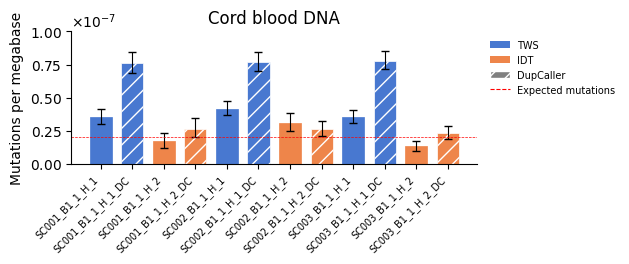

In [ ]:
plot_error_rate(mutrate=mutrates, samples=samples, outdir=OUTPUT_BASE, protocol_order=protocol_order)


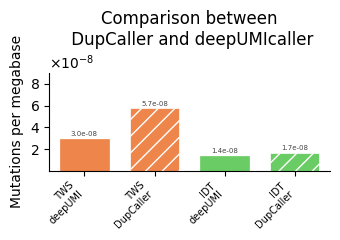

In [60]:
plot_density(mutdensity_dict=mutdensity_dict, outdir=OUTPUT_BASE)
